# Task 3

In [126]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm
from itertools import product

from tools.pcd_tools import downsample_voxel, pcd_from_path, boundaries
from tools.plot_tools import plot_pcd, show_pcl, view_frames, plot_map_and_trajectories
from tools.analysis_tools import calc_error
from tools.dataset import FrameDataset
from tools.ndt_tools import NDT, Pose  # Import the provided NDT implementation


In [127]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset

In [128]:
# set zero_z to True
zero_z = False

dataset = FrameDataset(FRAMES_DIR, GT_PATH, zero_z=zero_z)
map_pcd = pcd_from_path(MAP_PATH)

# convert map to 2d
if zero_z:
    map_pcd = np.c_[map_pcd[:, 0], map_pcd[:, 1], np.zeros(map_pcd.shape[0])]

print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


## Parameter Tuning

In [ ]:
from ipywidgets import FloatSlider, IntSlider, VBox, HBox, Label, Layout
from IPython.display import display

def update_plots(i, zmin, zmax, voxel_size, r):
    """Update all plots with the given parameters"""
    plt.close('all')  # Close any existing plots
    fig, ax = plt.subplots(3, 2, figsize=(12, 8))
    
    # Get the current frame
    pcd, _, _ = dataset[i]
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
    
    # Filter out points with z within range
    zlims = [zmin, zmax]
    pcd_voxel_boundaries = boundaries(pcd_voxel, r, zlims=zlims)
    
    map_pcd = pcd_from_path(MAP_PATH)
    map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)
    map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, r, zlims=zlims)
    
    # Plotting the point clouds with titles
    plot_pcd(ax[0, 0], pcd, s=0.1)
    ax[0, 0].set_title('Original Point Cloud')
    
    plot_pcd(ax[1, 0], pcd_voxel, s=0.1)
    ax[1, 0].set_title('Voxelized Point Cloud')
    
    plot_pcd(ax[2, 0], pcd_voxel_boundaries, s=0.1)
    ax[2, 0].set_title('Filtered Point Cloud Boundaries')
    
    plot_pcd(ax[0, 1], map_pcd, s=0.1)
    ax[0, 1].set_title('Map Point Cloud')
    
    plot_pcd(ax[1, 1], map_pcd_voxel, s=0.1)
    ax[1, 1].set_title('Map Voxelized Point Cloud')
    
    plot_pcd(ax[2, 1], map_pcd_voxel_boundaries, s=0.1)
    ax[2, 1].set_title('Map Filtered Point Cloud Boundaries')
    
    # Set common title with parameters
    fig.suptitle(f'Frame: {i}, Z-limits: [{zmin}, {zmax}], Voxel Size: {voxel_size}, Boundary Radius: {r}', 
                 fontsize=14)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
    
    # Instead of plt.show(), the figure will be displayed automatically by interactive_output

# Create the interactive display
def create_interactive_display():
    # Create sliders with reasonable ranges
    frame_slider = IntSlider(
        value=426, 
        min=0, 
        max=len(dataset)-1, 
        step=1, 
        description='Frame:',
        layout=Layout(width='50%')
    )
    
    zmin_slider = FloatSlider(
        value=0, 
        min=-10, 
        max=2, 
        step=0.1, 
        description='Z min:',
        layout=Layout(width='50%')
    )
    
    zmax_slider = FloatSlider(
        value=7, 
        min=2, 
        max=10, 
        step=0.1, 
        description='Z max:',
        layout=Layout(width='50%')
    )
    
    voxel_slider = FloatSlider(
        value=0.25, 
        min=0.01, 
        max=1.0, 
        step=0.01, 
        description='Voxel Size:',
        layout=Layout(width='50%')
    )
    
    radius_slider = FloatSlider(
        value=2.5, 
        min=0.5, 
        max=10, 
        step=0.1, 
        description='Radius:',
        layout=Layout(width='50%')
    )
    
    # Create interactive output
    from ipywidgets import interactive_output
    
    out = interactive_output(
        update_plots, 
        {
            'i': frame_slider, 
            'zmin': zmin_slider, 
            'zmax': zmax_slider,
            'voxel_size': voxel_slider,
            'r': radius_slider
        }
    )
    
    # Create UI layout
    slider_box = VBox([
        frame_slider,
        HBox([zmin_slider, zmax_slider]),
        HBox([voxel_slider, radius_slider])
    ])
    
    # Display the UI
    display(VBox([slider_box, out]))

# Run the interactive display
create_interactive_display()

## NDT Run

In [130]:
def run_ndt_tracking(dataset, map_pcd, params, run_id):
    """
    Run NDT-based tracking on a sequence of point clouds.
    
    Args:
        dataset: List of (point_cloud, position, orientation) tuples
        map_pcd: Point cloud of the map
        params: Dictionary containing parameters:
            - 'ndt_cell_size': Size of the cells in the NDT grid
            - 'ylim': Y-axis limits for the NDT
            - 'xlim': X-axis limits for the NDT
            - 'voxel_size_map': Voxel size for downsampling the map point cloud
            - 'voxel_size_scan': Voxel size for downsampling the scan point cloud
            - 'r_map': Radius for boundary detection in the map
            - 'r_scan': Radius for boundary detection in the scan
            - 'zlims': Z-axis limits for the point clouds
            - 'ndt_iterations': Maximum number of iterations for the NDT algorithm
            - 'frame_range': Tuple indicating the range of frames to process
        run_id: Integer ID for this run
    
    Returns:
        Dictionary containing tracking results
    """
    # Lists to track results
    gt_positions = []
    estimated_positions = []
    computation_times = []
    lateral_errors = []
    yaw_errors = []
    terminated_early = False

    early_stopping = params['early_stopping'] if 'early_stopping' in params else True

    # Get the initial pose from ground truth to initialize
    init_pcd, init_pos, init_orientation = dataset[params['frame_range'][0]]
    yaw = init_orientation[2]
    current_pose = Pose(init_pos[0], init_pos[1], yaw)

    # Process frames
    num_frames = min(len(dataset), params['frame_range'][1])
    pbar = tqdm(range(params['frame_range'][0], num_frames), 
                desc=f"Run {run_id}: Processing frames", leave=True)

    # Create NDT object
    ndt = NDT(params['ndt_cell_size'], params['ndt_cell_size'], 
              ylim=params['ylim'], xlim=params['xlim'])
    map_pcd_voxel, _ = downsample_voxel(map_pcd, params['voxel_size_map'])
    map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, params['r_map'], zlims=params['zlims'])
    ndt.set_input_cloud(map_pcd_voxel_boundaries)
    cumulative_error = 0
    max_error = 0

    for i in pbar:
        start_time = time.time()

        # Get the current frame
        pcd, gt_pos, gt_orientation = dataset[i]
        gt_positions.append(gt_pos)
        
        # Voxelize the point clouds to reduce complexity
        pcd_voxel, _ = downsample_voxel(pcd, params['voxel_size_scan'])
        pcd_voxel_boundaries = boundaries(pcd_voxel, params['r_scan'], zlims=params['zlims'])
 
        # Run NDT to align current scan with map
        pose, _ = ndt.align(pcd_voxel_boundaries, current_pose, 
                          max_iterations=params['ndt_iterations'], eps=0.001)
        
        # Create transformation matrix from NDT result
        estimated_position = np.array([pose.x, pose.y, 0.0])
        estimated_orientation = np.array([0.0, 0.0, pose.yaw])
        current_pose = pose
        
        # Store estimated position
        estimated_positions.append(estimated_position)
        
        # Compute error
        norm_error = np.linalg.norm(estimated_position - gt_pos)
        lateral_error, yaw_error = calc_error(gt_pos, gt_orientation, 
                                            estimated_position, estimated_orientation)
        lateral_errors.append(lateral_error)
        yaw_errors.append(yaw_error)
        cumulative_error += lateral_error
        if lateral_error > max_error:
            max_error = lateral_error
        
        # Check if error exceeds threshold
        if lateral_error > 1.2 and early_stopping:
            terminated_early = True
            pbar.set_postfix({
                "Norm Error": f"{norm_error:.2f}m",
                "Lateral Error": f"{lateral_error:.2f}m",
                "Yaw Error": f"{yaw_error:.2f}deg",
                "Time": f"{execution_time:.2f}s",
                "Cumulative Error": f"{cumulative_error:.2f}m",
                "Max Error": f"{max_error:.2f}m",
                "Status": "Terminated Early"
            })
            break
        
        # Compute execution time
        execution_time = time.time() - start_time
        computation_times.append(execution_time)
        
        # Update progress bar with current error
        pbar.set_postfix({
            "Norm Error": f"{norm_error:.2f}m",
            "Lateral Error": f"{lateral_error:.2f}m",
            "Yaw Error": f"{yaw_error:.2f}deg",
            "Time": f"{execution_time:.2f}s",
            "Cumulative Error": f"{cumulative_error:.2f}m",
            "Max Error": f"{max_error:.2f}m"
        })

    return {
        'gt_positions': gt_positions,
        'estimated_positions': estimated_positions,
        'computation_times': computation_times,
        'lateral_errors': lateral_errors,
        'yaw_errors': yaw_errors,
        'terminated_early': terminated_early
    }

In [131]:
params = {
    'voxel_size_scan': 0.45,
    'voxel_size_map': 0.45*4,
    'frame_range': [0, 1200],
    'ndt_cell_size': 5,
    'ndt_iterations': 10,
    'r_scan': 1.5,
    'r_map': 3,
    'zlims': [-1, 7],
    'ylim': None,
    'xlim': None,
    'early_stopping': False
}
results1 = run_ndt_tracking(dataset, map_pcd, params, None)

Run None: Processing frames:   0%|          | 0/1014 [00:00<?, ?it/s]

In [132]:
params = {
    'voxel_size_scan': 0.35,
    'voxel_size_map': 0.35*4,
    'frame_range': [0, 1200],
    'ndt_cell_size': 4,
    'ndt_iterations': 10,
    'r_scan': 1.5,
    'r_map': 3,
    'zlims': [-1, 7],
    'ylim': None,
    'xlim': None,
    'early_stopping': False
}
results2 = run_ndt_tracking(dataset, map_pcd, params, None)

Run None: Processing frames:   0%|          | 0/1014 [00:00<?, ?it/s]

In [133]:
params = {
    'voxel_size_scan': 0.25,
    'voxel_size_map': 0.5,
    'frame_range': [0, 1200],
    'ndt_cell_size': 4,
    'ndt_iterations': 10,
    'r_scan': 1.5,
    'r_map': 3,
    'zlims': [-1, 7],
    'ylim': None,
    'xlim': None,
    'early_stopping': False
}
results3 = run_ndt_tracking(dataset, map_pcd, params, None)

Run None: Processing frames:   0%|          | 0/1014 [00:00<?, ?it/s]

## Grid Search for parameters

Notable combinations:
- voxel_size_scan 0.25 and voxel_size_map *2 -> 1.9, 52 ce, 0.83 me
- voxel_size_scan 0.35 and voxel_size_map *2 -> 1.6, 44 ce, 0.96 me
- voxel_size_scan 0.5 and voxel_size_map *4 -> 0.8s, 52 ce, 1.04 me
- r_scan 1.5 and r_map *2

In [107]:
def run_parameter_search(dataset, map_pcd):
    # Define parameter ranges
    # param_grid = {
    #     'voxel_size_scan': [0.2, 0.35, 0.5],
    #     'voxel_size_map': [0.3, 0.5, 0.7],
    #     'ndt_cell_size': [1.0, 1.5, 2.0],
    #     'ndt_iterations': [5, 15, 30],
    #     'r_scan': [1.0, 1.5, 2.0],
    #     'r_map': [2.0, 3.0, 4.0],
    #     'zlim_min': [-2.0, -1.0, 0.0],  # Added new parameter
    #     'zlim_max': [5.0, 7.0, 9.0],    # Added new parameter
    # }
    param_grid = {
        'voxel_size_scan': [0.25],
        'voxel_size_map': [0.5],
        # 'voxel_size_map_factor': [1.8, 2.0, 2.2],
        'ndt_cell_size': [4],
        'ndt_iterations': [10],
        'r_scan': [1.5],
        'r_map': [3.0],
        # 'r_map_factor': [1.8, 2.0, 2.2],
        'zlim_min': [-1],
        'zlim_max': [7],
    }

    # Generate all parameter combinations
    param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

    # create new folder under /grid_search/ using timestamp
    grid_search_dir = f'grid_search/{time.strftime("%Y%m%d_%H%M%S")}'
    os.makedirs(grid_search_dir, exist_ok=True)

    # create results file
    results_file = os.path.join(grid_search_dir, 'results.csv')
    if os.path.exists(results_file):
        os.remove(results_file)
    

    # Initialize run ID
    run_id = 0
    
    # Run grid search with progress bar
    for params in tqdm(param_combinations, desc="Running parameter search"):
        run_id += 1

        # voxel size map = voxel size scan
        if 'voxel_size_map_factor' in params:
            params['voxel_size_map'] = params['voxel_size_scan'] * params['voxel_size_map_factor']
        
        if 'voxel_size_map' not in params:
            params['voxel_size_map'] = params['voxel_size_scan']
        
        if 'r_map_factor' in params:
            params['r_map'] = params['r_scan'] * params['r_map_factor']
        
        if 'r_map' not in params:
            params['r_map'] = params['r_scan']
        
        # Add fixed parameters
        params['frame_range'] = [550, 650]
        params['zlims'] = [params['zlim_min'], params['zlim_max']]  # Changed to use the parameters
        params['ylim'] = None
        params['xlim'] = None
        
        try:
            # Run NDT tracking
            tracking_results = run_ndt_tracking(dataset, map_pcd, params, run_id)
            
            # Calculate metrics
            max_lateral_error = np.max(tracking_results['lateral_errors'])
            mean_lateral_error = np.mean(tracking_results['lateral_errors'])
            max_yaw_error = np.max(tracking_results['yaw_errors'])
            mean_yaw_error = np.mean(tracking_results['yaw_errors'])
            mean_computation_time = np.mean(tracking_results['computation_times'])
            
            # Create result dictionary
            result = {
                'run_id': run_id,
                **params,
                'max_lateral_error': max_lateral_error,
                'mean_lateral_error': mean_lateral_error,
                'max_yaw_error': max_yaw_error,
                'mean_yaw_error': mean_yaw_error,
                'mean_computation_time': mean_computation_time
            }
            
            # Convert to DataFrame and append to file
            result_df = pd.DataFrame([result])
            if os.path.exists(results_file):
                result_df.to_csv(results_file, mode='a', header=False, index=False)
            else:
                result_df.to_csv(results_file, index=False)
                
        except Exception as e:
            print(f"Error in run {run_id} with parameters {params}: {str(e)}")
            continue

    # Load and display final results
    try:
        results_df = pd.read_csv(results_file)
        if not results_df.empty:
            # Sort by max lateral error (primary metric)
            results_df = results_df.sort_values('max_lateral_error')

            # Display top 10 parameter combinations
            print("\nTop 10 parameter combinations:")
            print(results_df.head(10).to_string())

            # Plot results
            plt.figure(figsize=(15, 10))

            # Plot max lateral error vs mean computation time
            plt.subplot(2, 2, 1)
            plt.scatter(results_df['mean_computation_time'], results_df['max_lateral_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Max Lateral Error (m)')
            plt.title('Max Lateral Error vs Computation Time')
            plt.grid(True)

            # Plot mean lateral error vs mean computation time
            plt.subplot(2, 2, 2)
            plt.scatter(results_df['mean_computation_time'], results_df['mean_lateral_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Mean Lateral Error (m)')
            plt.title('Mean Lateral Error vs Computation Time')
            plt.grid(True)

            # Plot max yaw error vs mean computation time
            plt.subplot(2, 2, 3)
            plt.scatter(results_df['mean_computation_time'], results_df['max_yaw_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Max Yaw Error (deg)')
            plt.title('Max Yaw Error vs Computation Time')
            plt.grid(True)

            # Plot mean yaw error vs mean computation time
            plt.subplot(2, 2, 4)
            plt.scatter(results_df['mean_computation_time'], results_df['mean_yaw_error'])
            plt.xlabel('Mean Computation Time (s)')
            plt.ylabel('Mean Yaw Error (deg)')
            plt.title('Mean Yaw Error vs Computation Time')
            plt.grid(True)

            plt.tight_layout()
            plt.show()
        else:
            print("No valid results to display")
    except FileNotFoundError:
        print("No results file found")

    return results_df

Running parameter search:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1: Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]

Run 2: Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]

Error in run 2 with parameters {'voxel_size_scan': 0.25, 'voxel_size_map': 0.5, 'ndt_cell_size': 4, 'ndt_iterations': 10, 'r_scan': 1.5, 'r_map': 3.0, 'zlim_min': -1, 'zlim_max': 7, 'zero_z': 1, 'frame_range': [550, 650], 'zlims': [-1, 7], 'ylim': None, 'xlim': None}: zero-size array to reduction operation minimum which has no identity


Run 3: Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]

Error in run 3 with parameters {'voxel_size_scan': 0.25, 'voxel_size_map': 0.5, 'ndt_cell_size': 4, 'ndt_iterations': 10, 'r_scan': 1.5, 'r_map': 3.0, 'zlim_min': -1, 'zlim_max': 7, 'zero_z': 2, 'frame_range': [550, 650], 'zlims': [-1, 7], 'ylim': None, 'xlim': None}: zero-size array to reduction operation minimum which has no identity


Run 4: Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]


Top 10 parameter combinations:
   run_id  voxel_size_scan  voxel_size_map  ndt_cell_size  ndt_iterations  r_scan  r_map  zlim_min  zlim_max  zero_z frame_range    zlims  ylim  xlim  max_lateral_error  mean_lateral_error  max_yaw_error  mean_yaw_error  mean_computation_time
0       1             0.25             0.5              4              10     1.5    3.0        -1         7       0  [550, 650]  [-1, 7]   NaN   NaN           1.096369            0.510072      -0.000642       -0.009873               2.017275
1       4             0.25             0.5              4              10     1.5    3.0        -1         7       3  [550, 650]  [-1, 7]   NaN   NaN           1.383441            0.641194       0.005624        0.000186               1.962124


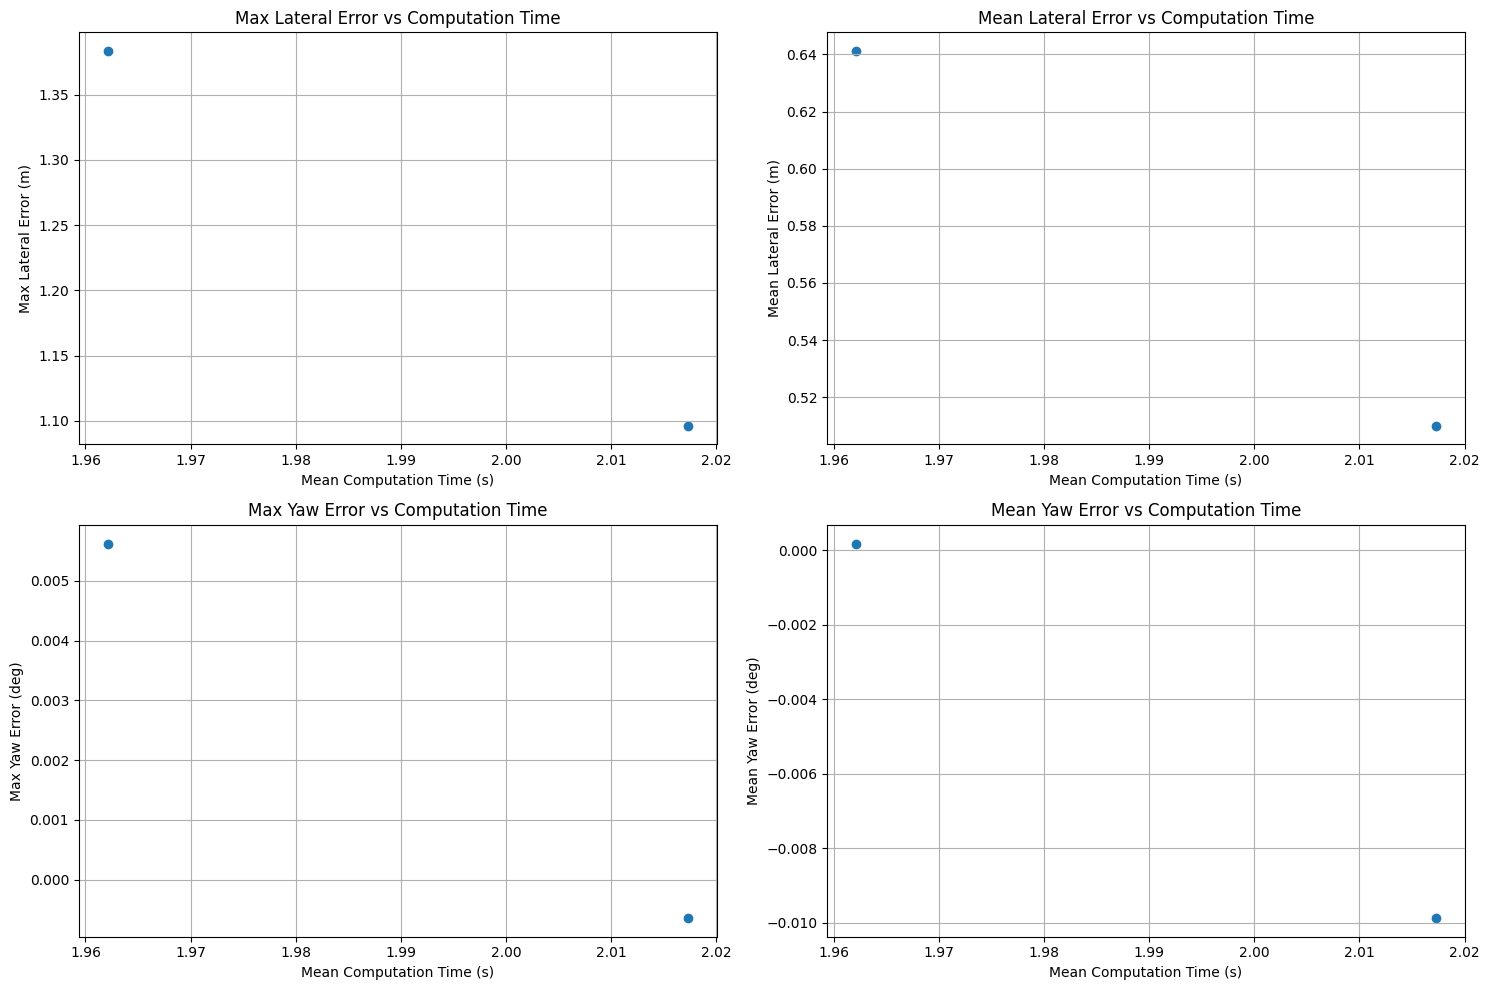

In [108]:
# Run parameter search
results_df = run_parameter_search(dataset, map_pcd)

## Analysis

In [134]:
def plot_results(results):
    gt_positions = results['gt_positions']
    estimated_positions = results['estimated_positions']
    computation_times = results['computation_times']
    lateral_errors = results['lateral_errors']
    yaw_errors = results['yaw_errors']

    # Convert lists to numpy arrays
    gt_positions = np.array(gt_positions)
    estimated_positions = np.array(estimated_positions)
    computation_times = np.array(computation_times)
    lateral_errors = np.array(lateral_errors)
    yaw_errors = np.array(yaw_errors)

    max_lateral_error = np.max(lateral_errors)
    max_norm_error = np.max(np.linalg.norm(estimated_positions - gt_positions, axis=1))

    # Plot results
    plt.figure(figsize=(12, 8))

    # Plot lateral and norm error over frames in the same plot
    plt.plot(lateral_errors, label='Lateral Error')
    plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')

    # Mark the position of the max lateral error
    max_error_index = np.argmax(lateral_errors)
    plt.scatter(max_error_index, max_lateral_error, color='red', s=100, label=f'Max Lateral Error: {max_lateral_error:.2f} m')
    plt.text(max_error_index, max_lateral_error, f'{max_lateral_error:.2f} m', fontsize=9, ha='right')

    plt.title("Lateral and Norm Error over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Error (meters)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Calculate cumulative errors
    cumulative_lateral_errors = np.cumsum(lateral_errors)
    cumulative_norm_errors = np.cumsum(np.linalg.norm(estimated_positions - gt_positions, axis=1))

    # Plot cumulative lateral errors
    plt.figure(figsize=(12, 8))
    plt.plot(cumulative_lateral_errors, label='Cumulative Lateral Error')
    plt.title("Cumulative Lateral Error over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Cumulative Error (meters)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot cumulative norm errors
    plt.figure(figsize=(12, 8))
    plt.plot(cumulative_norm_errors, label='Cumulative Norm Error', color='orange')
    plt.title("Cumulative Norm Error over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Cumulative Error (meters)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot computation times across frames
    plt.figure(figsize=(12, 8))
    plt.plot(computation_times, label='Computation Time', color='purple')
    plt.title("Computation Times over Frames")
    plt.xlabel("Frame")
    plt.ylabel("Time (seconds)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)

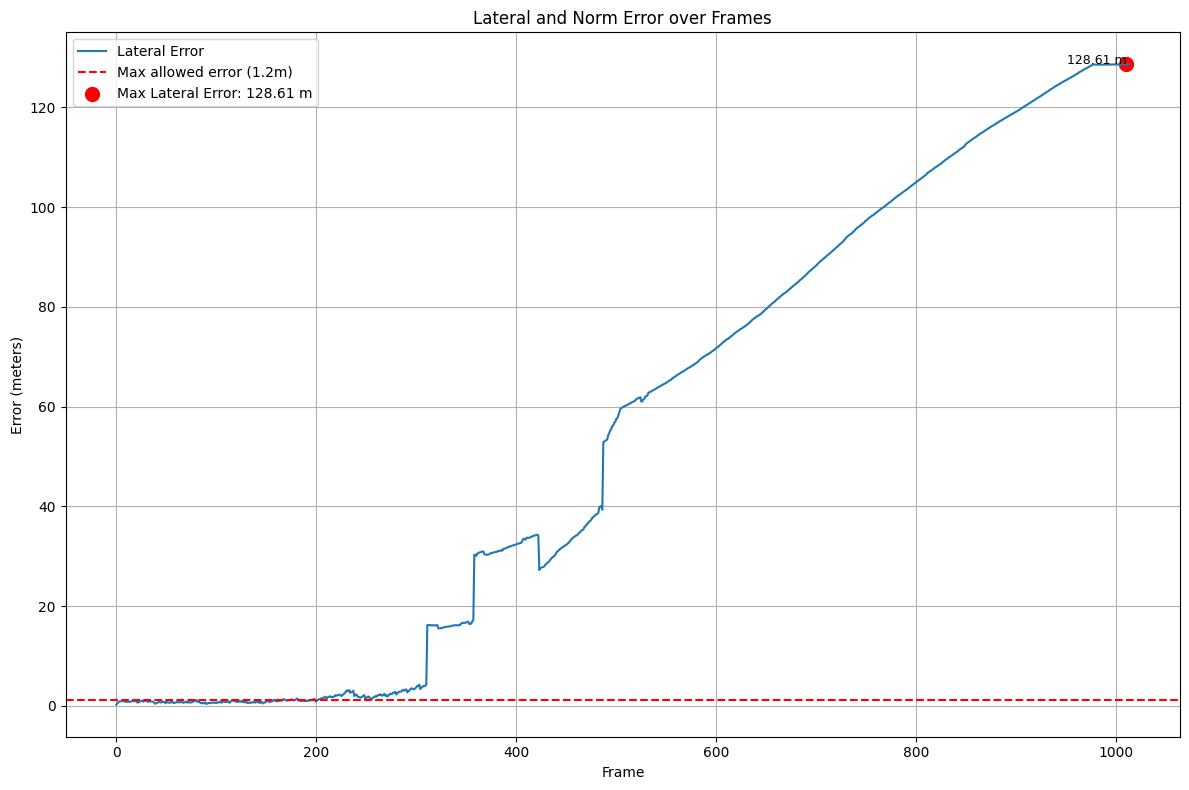

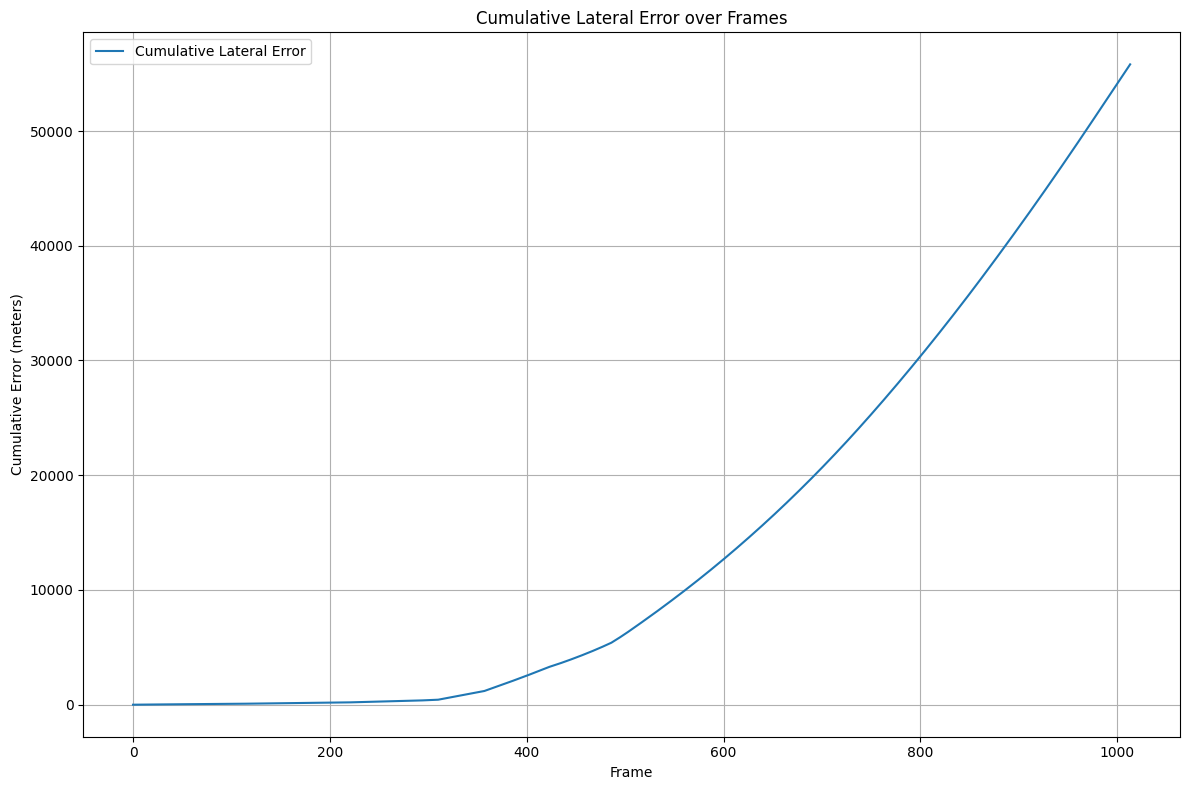

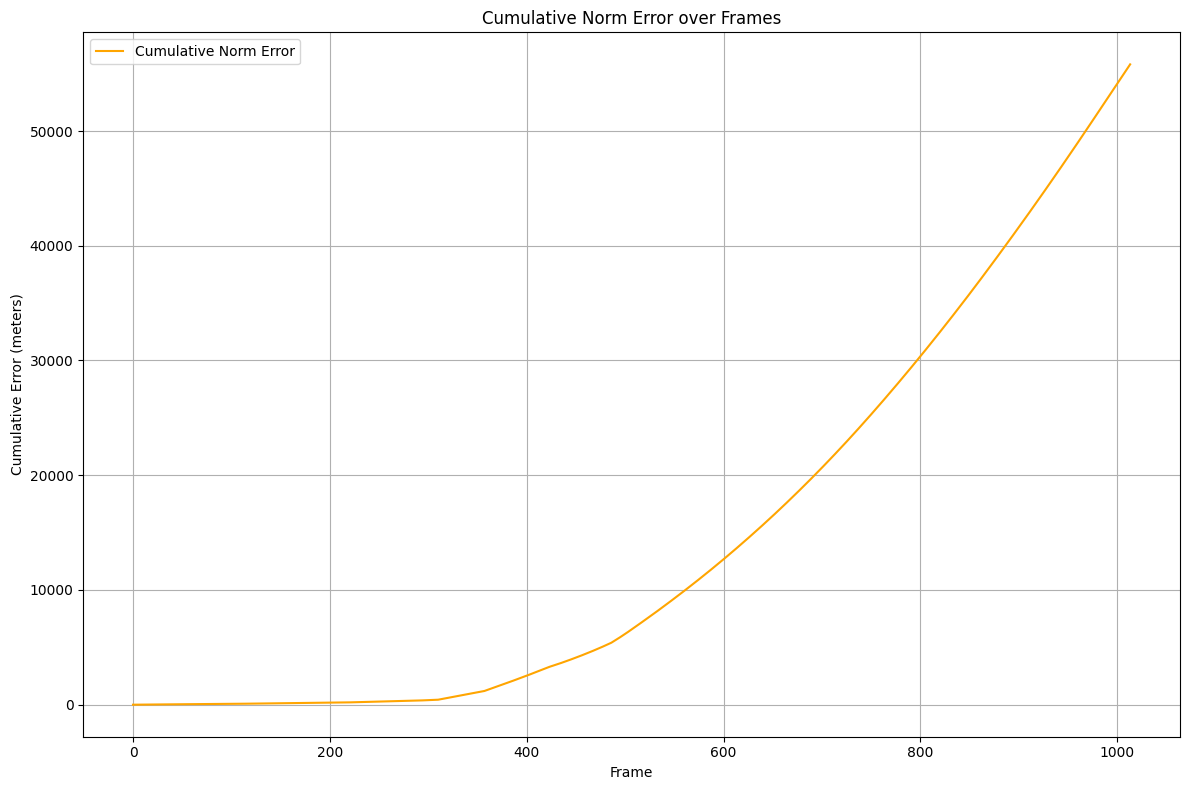

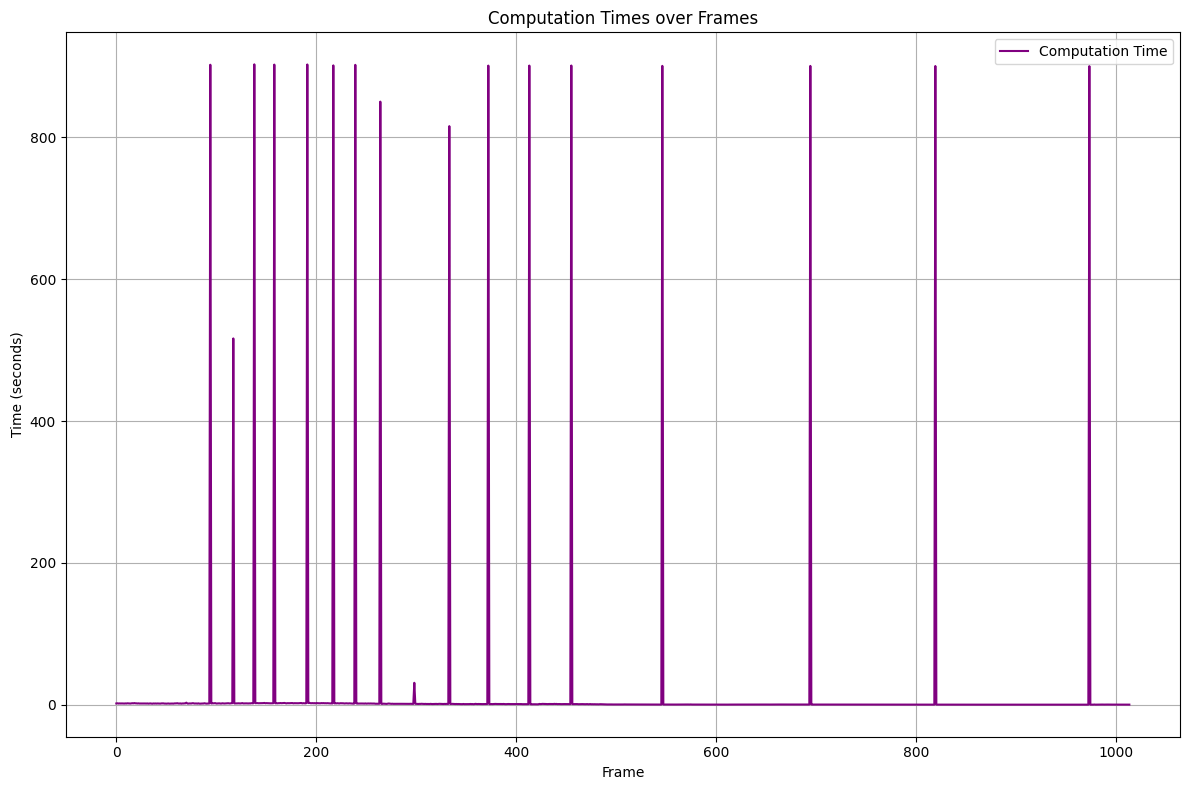

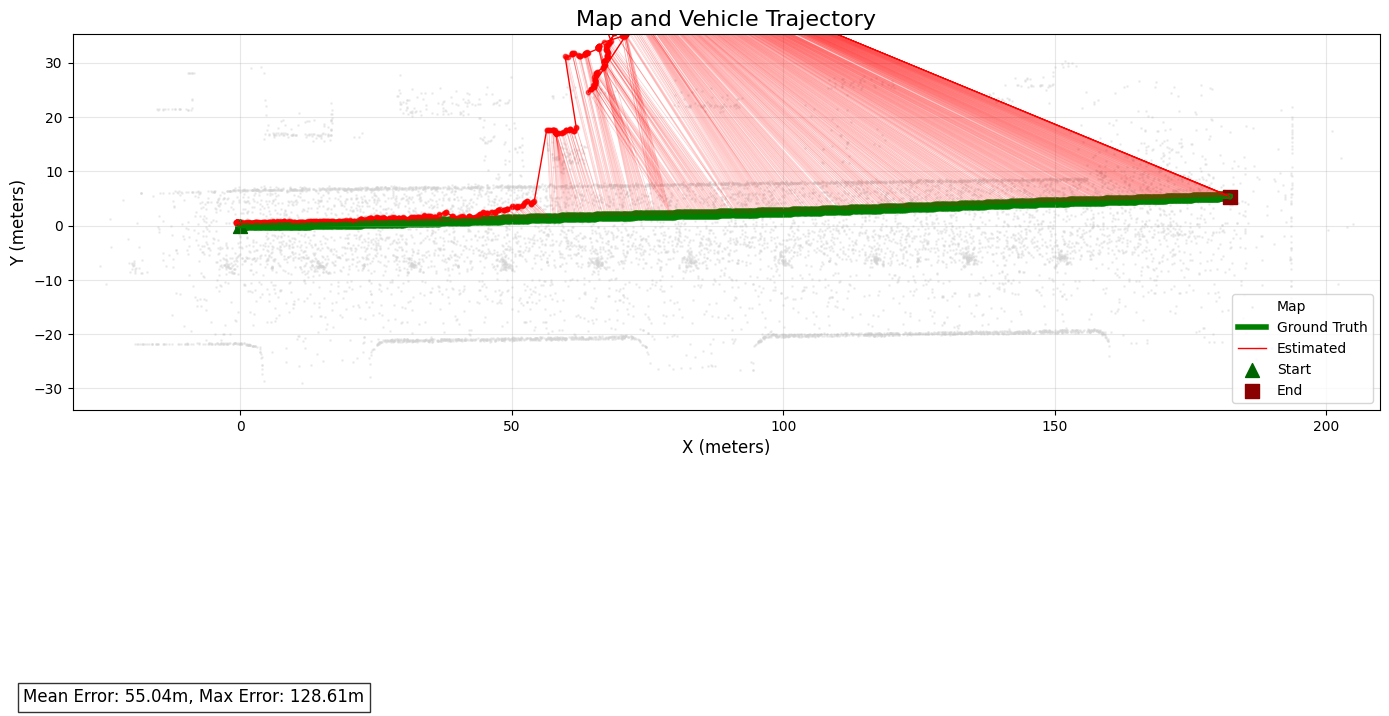

In [135]:

plot_results(results1)

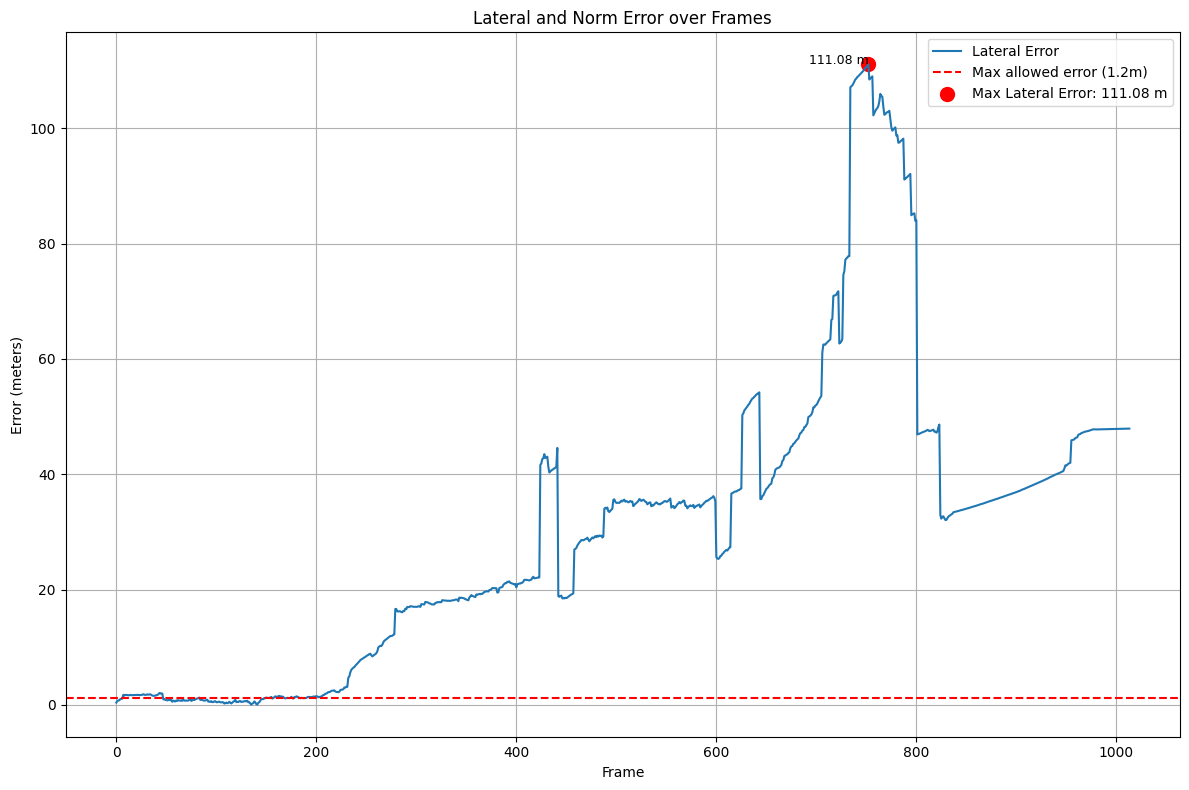

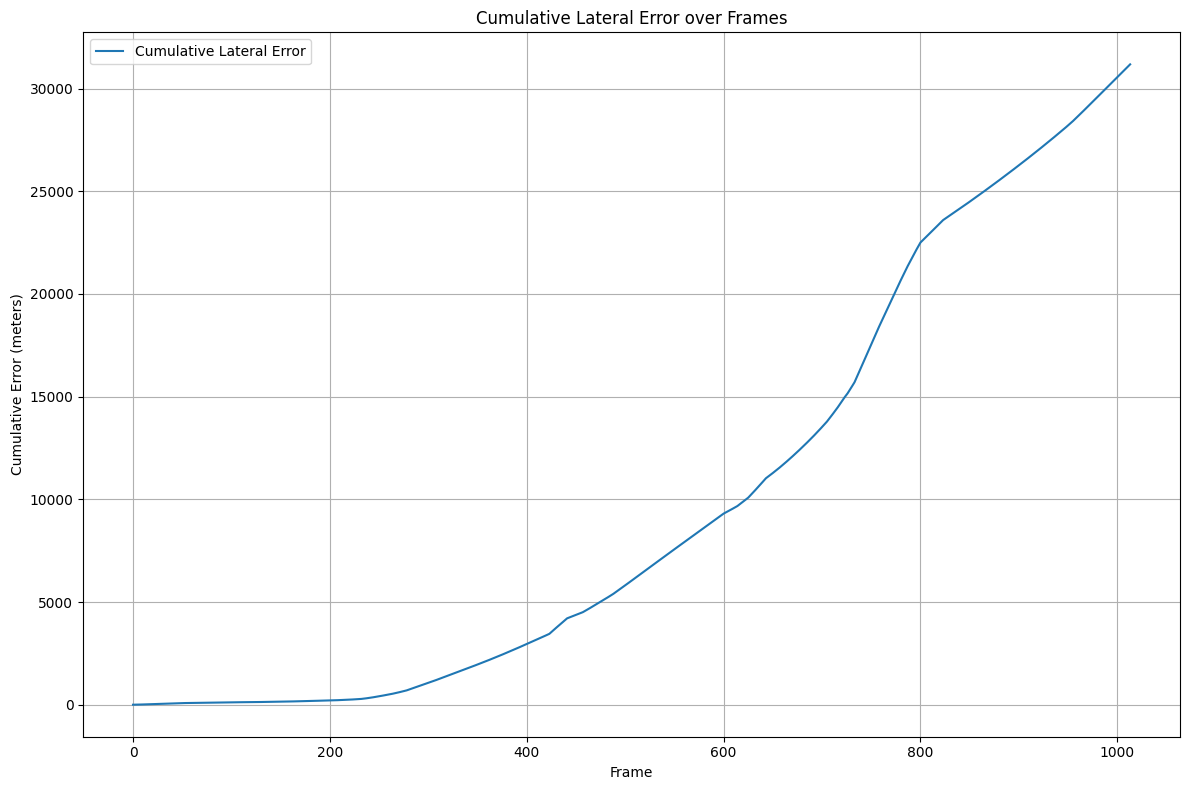

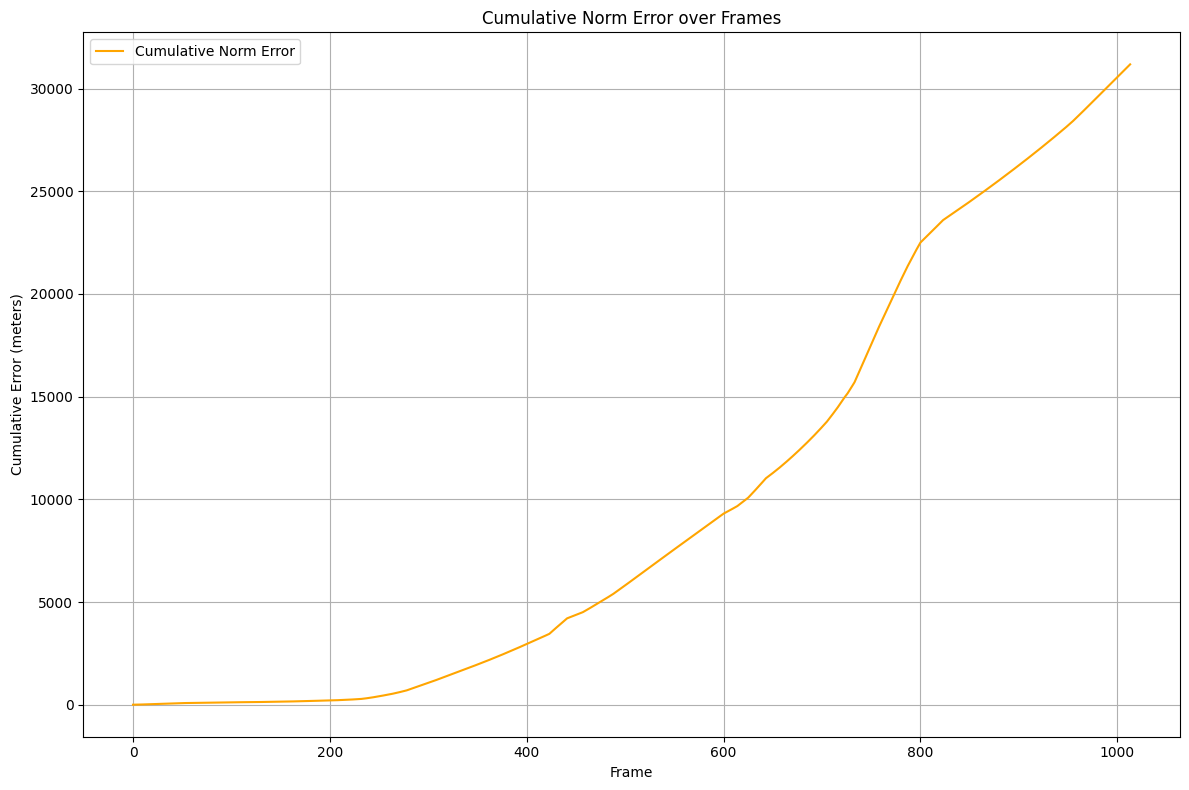

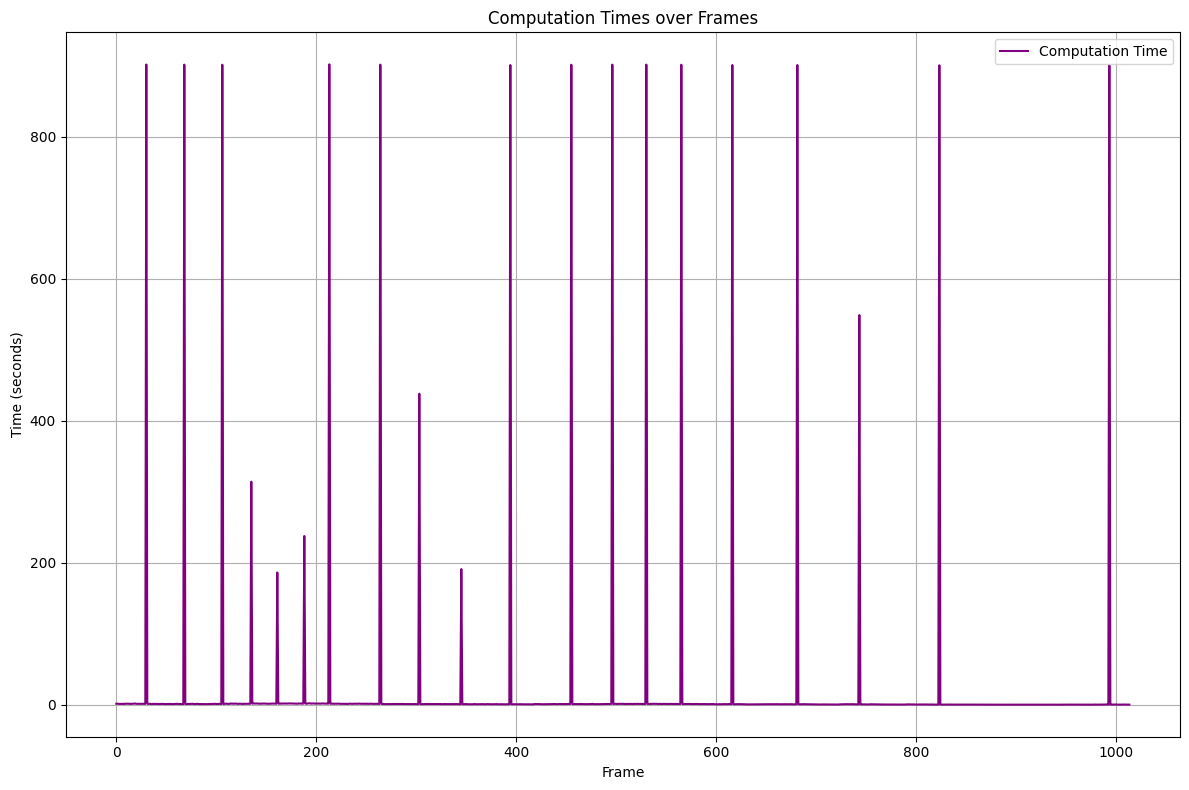

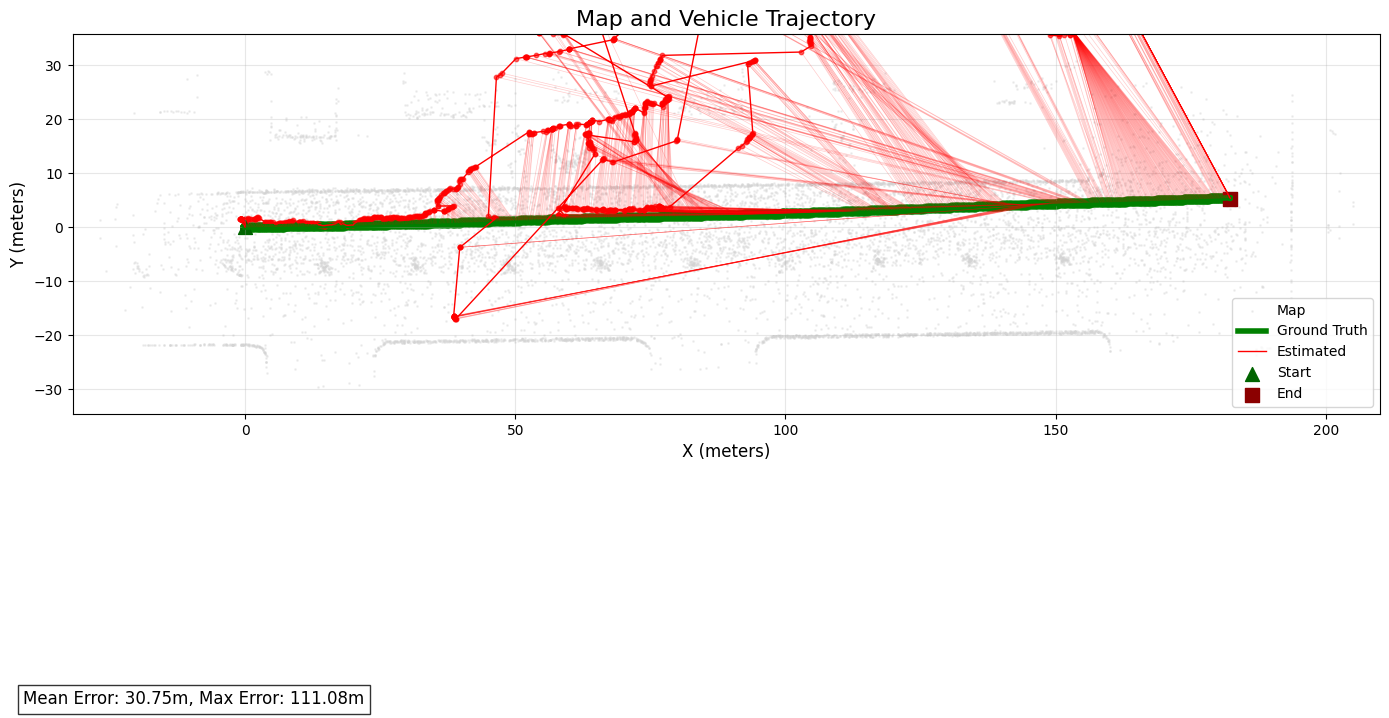

In [136]:
plot_results(results2)

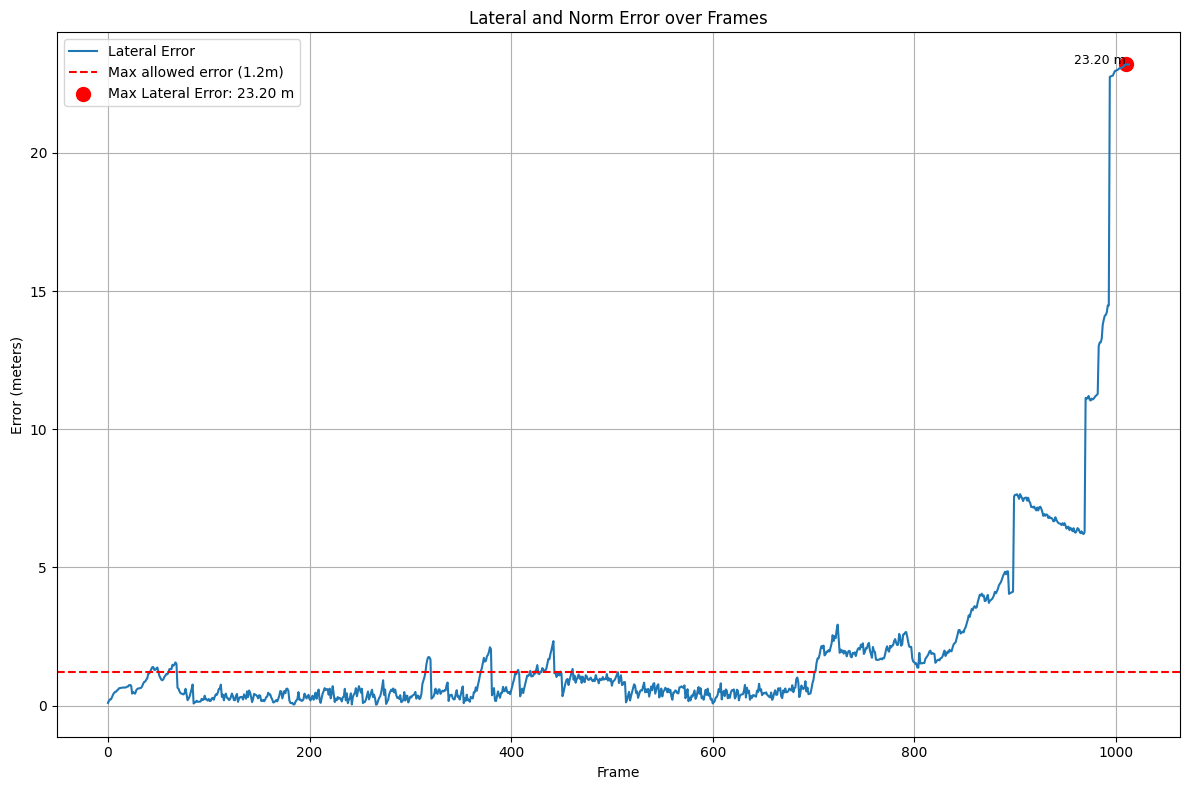

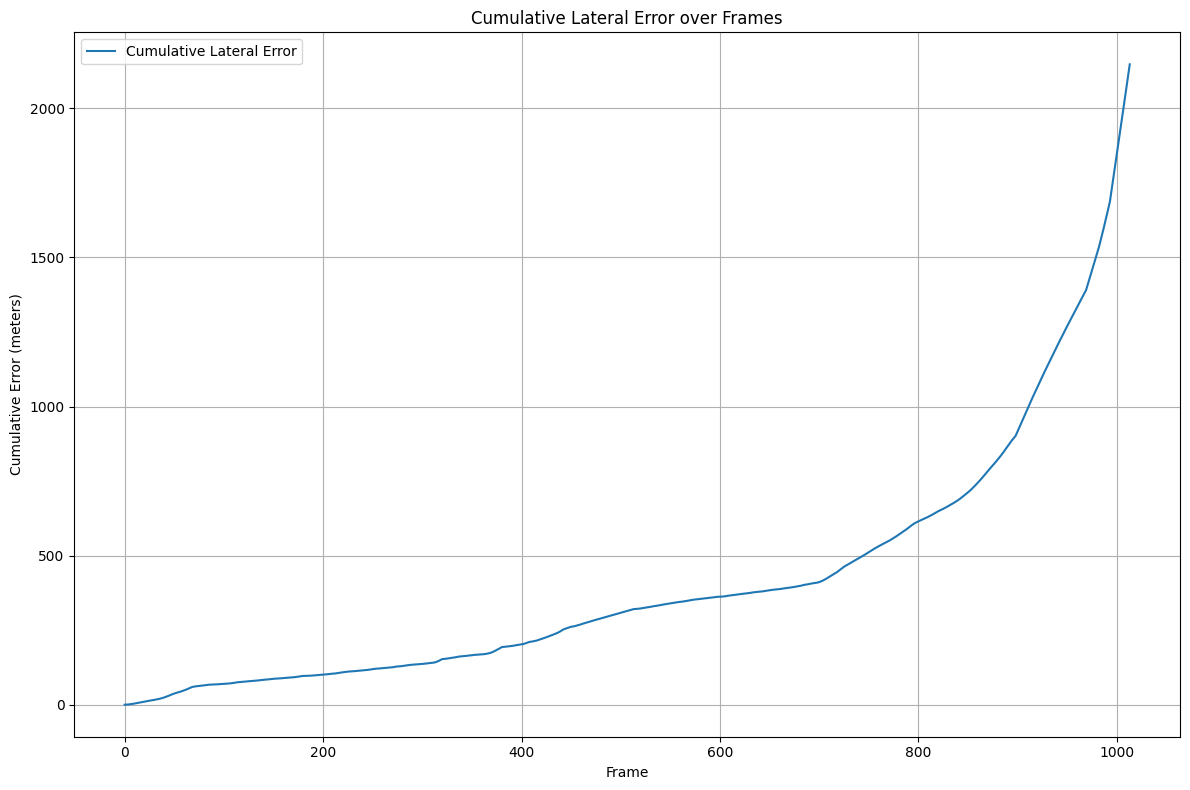

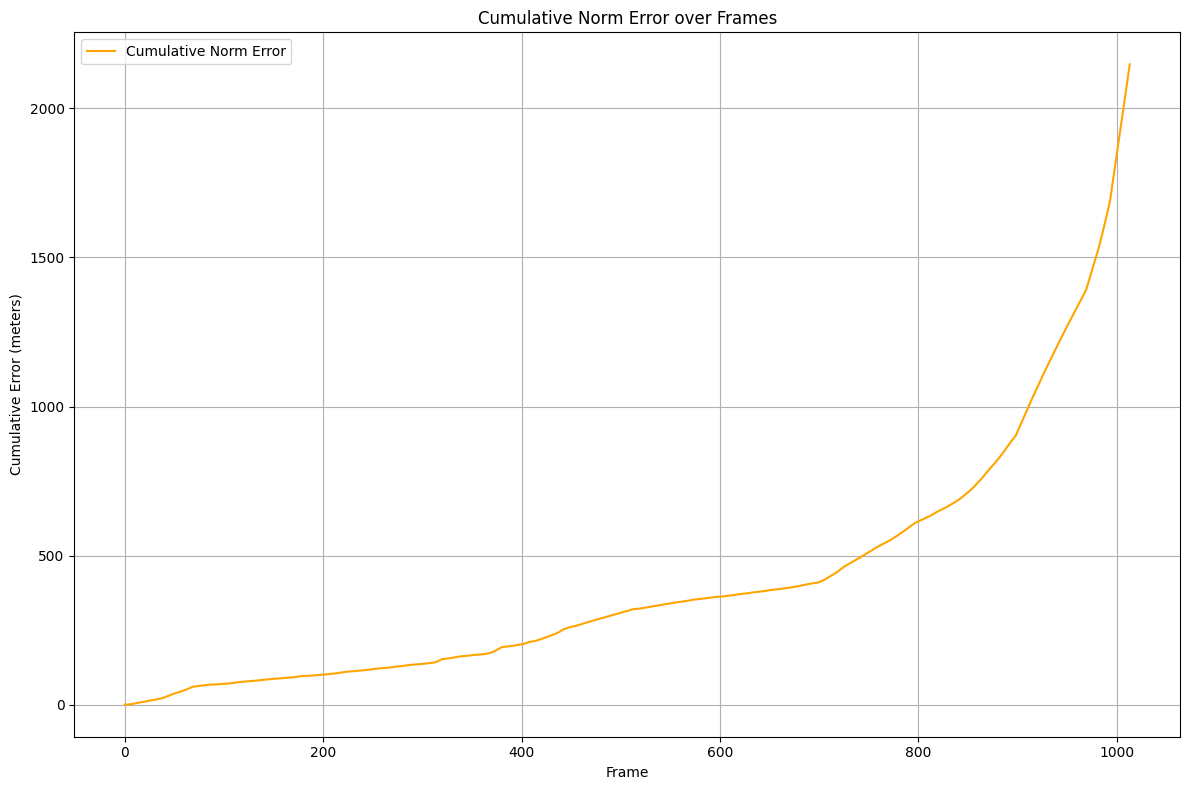

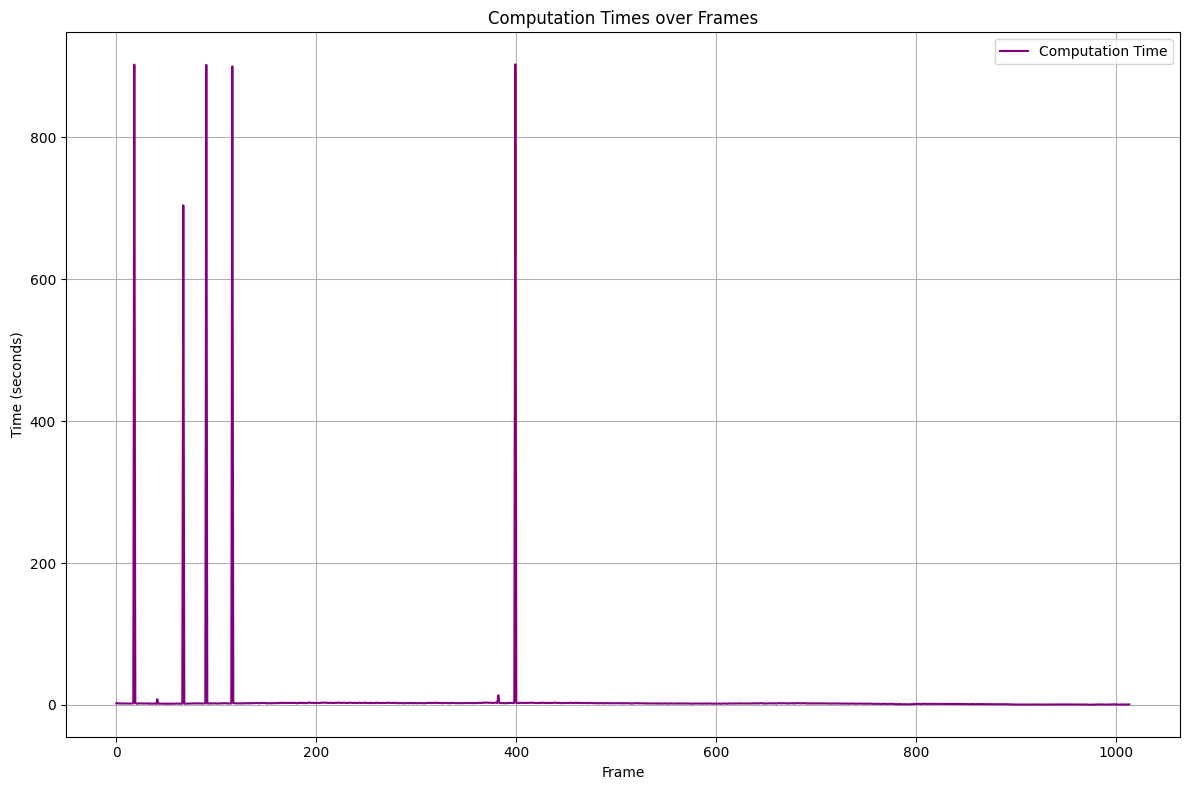

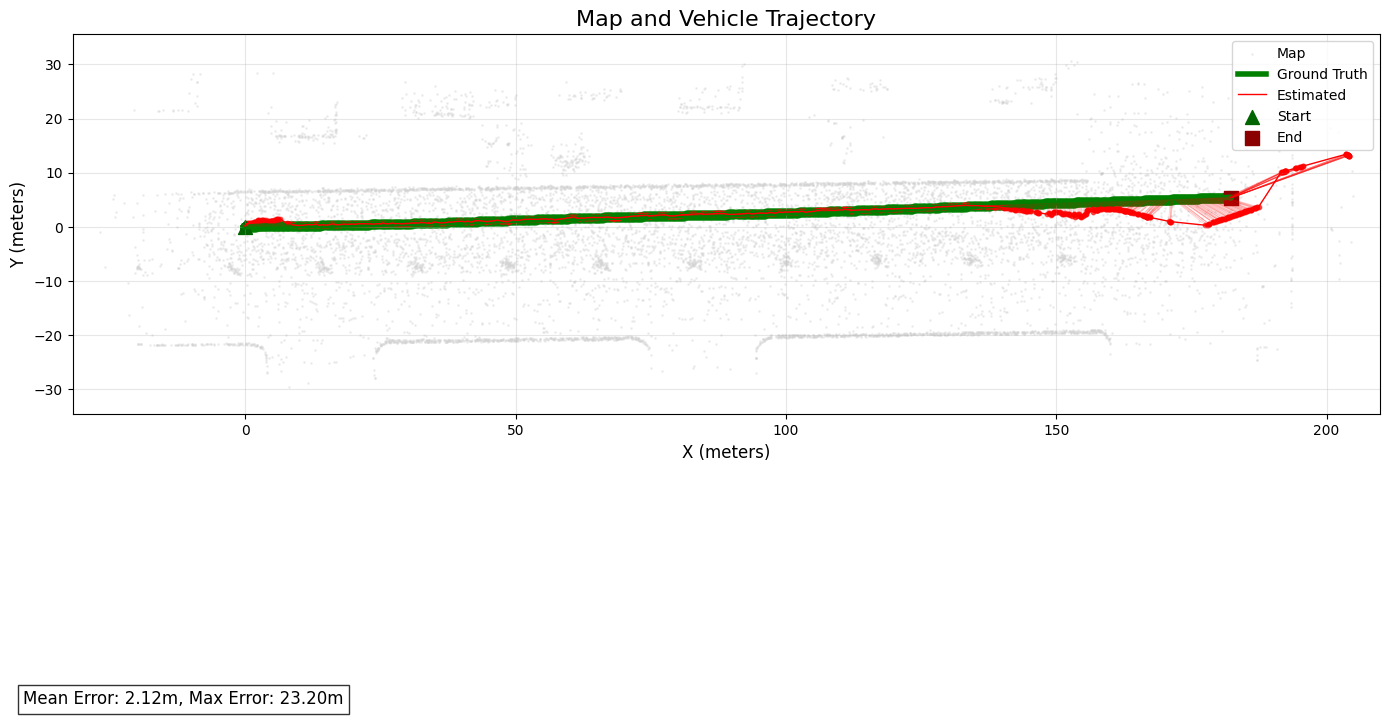

In [137]:
plot_results(results3)

In [138]:
import pickle

def save_results(results, filename):
    """Pickle the results dictionary and save it to a file."""
    with open(filename, 'wb') as file:
        pickle.dump(results, file)

def load_results(filename):
    """Load the pickled results dictionary from a file."""
    with open(filename, 'rb') as file:
        return pickle.load(file)


In [139]:

save_results(results1, 'results1.pkl')
save_results(results2, 'results2.pkl')
save_results(results3, 'results3.pkl')